# Two-tracer redshift-space power spectra with FOLPS

This notebook computes the equal-time redshift-space power-spectrum multipoles


$P_\ell^{AA}(k),\qquad
P_\ell^{AB}(k),\qquad
P_\ell^{BA}(k),\qquad
P_\ell^{BB}(k),$

for two illustrative biased tracers: an LRG-like tracer \(A\) and an ELG-like tracer \(B\). The auto spectra \(AA\) and \(BB\) are included so the cross spectrum can be compared against familiar single-tracer outputs and regression limits.

The calculation uses the NumPy backend and only public files shipped with this repository. It assumes one common effective redshift, common matter and velocity fields, no velocity bias, the plane-parallel approximation, even multipoles, explicit pair-level `cross_nuisance`, and `A_full=True`. The baseline examples use the standard EFT power-spectrum model with `model="EFT"` and `damping=None`; the damping section switches to `model="FOLPSD"` and illustrates the public cross damping modes.

Current limitations are deliberately narrow: no bispectrum cross-correlations, odd multipoles, wide-angle or relativistic corrections, DESI window convolution, mock likelihoods, desilike integration, redshift averaging, tracer-dependent velocity bias, or first-principles preference between phenomenological cross-damping prescriptions are included here.


## Imports and backend

FOLPS selects its array backend at import time, so the backend environment variable is set in the first code cell before importing the package.


In [1]:
import os
import sys
import tempfile
import time

os.environ["FOLPS_BACKEND"] = "numpy"
sys.dont_write_bytecode = True

# Keep Matplotlib cache writes out of user-level directories during execution.
_mpl_config_dir = tempfile.TemporaryDirectory(prefix="folps_mplconfig_")
os.environ["MPLCONFIGDIR"] = _mpl_config_dir.name

notebook_start = time.perf_counter()


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from folps import (
    MatrixCalculator,
    NonLinearPowerSpectrumCalculator,
    RSDMultipolesPowerSpectrumCalculator,
)

np.set_printoptions(precision=6, suppress=True)


Matplotlib is building the font cache; this may take a moment.


✅ Using NumPy with CPU.


## Locate the public input power spectrum

The repository quickstart and tests use the bundled fallback linear power spectrum at `folps/inputpkT.txt`. The existing NumPy notebook describes the input as using Mpc/h conventions, and the repository plots use \(k\) in \(h\,\mathrm{Mpc}^{-1}\). The file itself has no header with independent unit metadata, so the labels below follow the repository convention.


Linear power file: folps/inputpkT.txt
Loaded 1000 samples
k range: 0.0001 to 2 h/Mpc
P_L range: 9.5209 to 16660


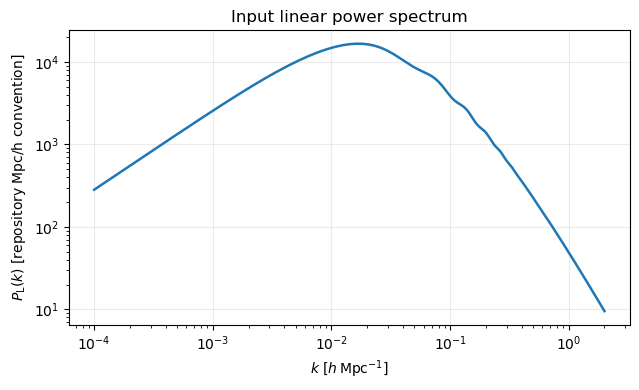

In [3]:
def find_repo_root(start):
    for candidate in (start, *start.parents):
        if (candidate / "folps" / "__init__.py").exists() and (candidate / "folps" / "inputpkT.txt").exists():
            return candidate
    raise FileNotFoundError("Could not find the FolpsD repository root from the current working directory.")


repo_root = find_repo_root(Path.cwd())
input_power_path = repo_root / "folps" / "inputpkT.txt"

k_input, P_linear_input = np.loadtxt(input_power_path, unpack=True)
print(f"Linear power file: {input_power_path.relative_to(repo_root)}")
print(f"Loaded {k_input.size} samples")
print(f"k range: {k_input.min():.5g} to {k_input.max():.5g} h/Mpc")
print(f"P_L range: {P_linear_input.min():.5g} to {P_linear_input.max():.5g}")

fig, ax = plt.subplots(figsize=(6.5, 4.0))
ax.loglog(k_input, P_linear_input, color="tab:blue", lw=1.8)
ax.set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
ax.set_ylabel(r"$P_\mathrm{L}(k)$ [repository Mpc/h convention]")
ax.set_title("Input linear power spectrum")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## Cosmology and loop-table construction

We use the same representative fallback cosmology as the repository README and NumPy tests. The FFTLog matrices are cosmology independent kernels used to assemble one-loop density, velocity, \(A\), \(D\), and related terms. The equal-time cross spectrum polarizes the existing auto-spectrum contractions, so no additional FFTLog matrices are needed for \(P^{AB}\).

`table` contains the nonlinear loop ingredients evaluated on the FOLPS output grid for the wiggle linear spectrum. `table_now` is the matching no-wiggle table used by the IR-resummation machinery. Setting `A_full=True` includes the additional biased pieces of the \(A\) function involving \(b_2\) and \(b_{s^2}\). Setting `use_TNS_model=False` keeps the standard EFT construction used by the cross-power API; the current cross implementation does not introduce the FolpsD/TNS phenomenological damping path.

The existing matrix cache is used through `folps/output_matrices`. If that public cache is missing, this tutorial stops rather than creating a new production matrix file.


In [4]:
cosmo = {
    "z": 0.3,
    "h": 0.6711,
    "Omega_m": 0.3211636237981114,
    "f0": np.float64(0.6880638641959066),
    "fnu": 0.004453689063655854,
}

matrix_dir_abs = repo_root / "folps" / "output_matrices"
matrix_cache = matrix_dir_abs / "matrices_nfftlog128_Afull-True_use_TNS-False.npy"
if not matrix_cache.exists():
    raise FileNotFoundError(
        f"Expected matrix cache {matrix_cache.relative_to(repo_root)} was not found."
    )

matrix_dir = Path(os.path.relpath(matrix_dir_abs, Path.cwd()))

with np.errstate(divide="ignore", invalid="ignore"):
    t0 = time.perf_counter()
    matrix = MatrixCalculator(
        A_full=True,
        use_TNS_model=False,
        save_dir=str(matrix_dir),
    )
    mmatrices = matrix.get_mmatrices()
    matrix_elapsed = time.perf_counter() - t0

    nonlinear = NonLinearPowerSpectrumCalculator(
        mmatrices=mmatrices,
        kernels="fk",
        **cosmo,
    )

    t0 = time.perf_counter()
    table, table_now = nonlinear.calculate_loop_table(
        k=k_input,
        pklin=P_linear_input,
        cosmo=None,
        **cosmo,
    )
    table_elapsed = time.perf_counter() - t0

print(f"Matrix step elapsed: {matrix_elapsed:.3f} s")
print(f"Loop-table step elapsed: {table_elapsed:.3f} s")
print(f"table rows: {len(table)}, table_now rows: {len(table_now)}")
print(f"FOLPS output k samples: {len(table[0])}")


Loading matrices from ../folps/output_matrices/matrices_nfftlog128_Afull-True_use_TNS-False.npy
Matrix step elapsed: 0.003 s
Loop-table step elapsed: 0.047 s
table rows: 36, table_now rows: 38
FOLPS output k samples: 120


## Prior-document bias convention

This tutorial uses the DESI prior-document bias convention at the public multipole API boundary. In this convention, users provide the first four tracer parameters as

$[b_1,b_2,b_{K^2},b_{\mathrm{td}}]$

Every auto-spectrum multipole call below passes `bias_scheme="priordoc"`. Every cross-spectrum multipole call passes `bias_scheme="priordoc"` for the tracer supplied through `pars` and `bias_scheme_b="priordoc"` for the tracer supplied through `pars_b`.

The current `set_bias_scheme` implementation maps the prior-document inputs to the canonical internal FOLPS basis as

$b_{s^2}=2b_{K^2}$,

and

$b_{3\mathrm{nl}} = -\frac{32}{21}\left(b_{K^2}+\frac{2}{5}b_{\mathrm{td}}\right)$


FOLPS performs this conversion internally before evaluating the loop terms. The auto- and cross-spectrum calculations still use the same pair-level contraction in the canonical basis, and the cross-spectrum implementation does not introduce a separate bias convention.

## Define two tracers

The FOLPS power-spectrum parameter vector in this notebook uses the prior-document order below.

| Index | Name | Meaning in this tutorial |
|---:|---|---|
| 0 | `b1` | Linear Eulerian bias for the tracer density field. |
| 1 | `b2` | Quadratic density-bias coefficient. |
| 2 | `bK2` | Prior-document tidal-bias coefficient. |
| 3 | `btd` | Prior-document third-order tidal-derivative bias coefficient. |
| 4 | `alpha0` | Isotropic EFT counterterm coefficient for an auto spectrum. |
| 5 | `alpha2` | $\mu^2$ EFT counterterm coefficient for an auto spectrum. |
| 6 | `alpha4` | $\mu^4$ EFT counterterm coefficient for an auto spectrum. |
| 7 | `ctilde` | Higher-derivative/NLO counterterm amplitude. |
| 8 | `alphashot0` | Constant stochastic amplitude multiplier. |
| 9 | `alphashot2` | $(k\mu)^2$ stochastic amplitude multiplier. |
| 10 | `PshotP` | Stochastic normalization. |
| 11 | `X_FoG_p` | Auto-spectrum phenomenological damping parameter, used below only in the FolpsD damping examples. |

The first four entries are tracer bias parameters in the prior-document basis. The remaining eight entries are auto-spectrum nuisance parameters. The auto nuisance values attached to `pars_a` and `pars_b` are used in the \(AA\) and \(BB\) calls. The cross spectrum uses a separate explicit `cross_nuisance` defined in the next section.

These LRG-like and ELG-like values are illustrative examples chosen to keep the tutorial numerically well behaved; they are not DESI best-fit parameters.


In [5]:
def coevolution_bK2(b1):
    return -2.0 / 7.0 * (b1 - 1.0)


def coevolution_btd(b1):
    return 23.0 / 42.0 * (b1 - 1.0)


def canonical_bias_from_priordoc(values):
    b1, b2, bK2, btd = values[:4]
    bs2 = 2.0 * bK2
    b3nl = -32.0 / 21.0 * (bK2 + 2.0 / 5.0 * btd)
    return np.asarray([b1, b2, bs2, b3nl])


b1_a = 1.645
b2_a = 0.2
bK2_a = coevolution_bK2(b1_a)
btd_a = coevolution_btd(b1_a)
alpha0_a = 0.7
alpha2_a = -1.3
alpha4_a = 0.2
ctilde_a = 0.0
alphashot0_a = 0.015
alphashot2_a = -0.45
PshotP_a = 4800.0
X_FoG_a = 0.0

pars_a = [
    b1_a,
    b2_a,
    bK2_a,
    btd_a,
    alpha0_a,
    alpha2_a,
    alpha4_a,
    ctilde_a,
    alphashot0_a,
    alphashot2_a,
    PshotP_a,
    X_FoG_a,
]

b1_b = 1.10
b2_b = -0.23
bK2_b = coevolution_bK2(b1_b)
btd_b = coevolution_btd(b1_b)
alpha0_b = 0.2
alpha2_b = -0.4
alpha4_b = 0.1
ctilde_b = 0.0
alphashot0_b = 0.0
alphashot2_b = 0.0
PshotP_b = 3600.0
X_FoG_b = 0.0

pars_b = [
    b1_b,
    b2_b,
    bK2_b,
    btd_b,
    alpha0_b,
    alpha2_b,
    alpha4_b,
    ctilde_b,
    alphashot0_b,
    alphashot2_b,
    PshotP_b,
    X_FoG_b,
]

parameter_names = [
    "b1", "b2", "bK2", "btd",
    "alpha0", "alpha2", "alpha4", "ctilde",
    "alphashot0", "alphashot2", "PshotP", "X_FoG_p",
]
canonical_bias_names = ["b1", "b2", "bs2", "b3nl"]
bias_mapper = RSDMultipolesPowerSpectrumCalculator(model="EFT")

for label, values in (("A, LRG-like", pars_a), ("B, ELG-like", pars_b)):
    prior_summary = ", ".join(f"{name}={value:.6g}" for name, value in zip(parameter_names[:4], values[:4]))
    canonical_expected = canonical_bias_from_priordoc(values)
    canonical_folps = np.asarray(bias_mapper.set_bias_scheme(values, bias_scheme="priordoc")[:4])
    assert np.allclose(canonical_folps, canonical_expected)
    canonical_summary = ", ".join(
        f"{name}={value:.6g}" for name, value in zip(canonical_bias_names, canonical_folps)
    )
    print(f"{label} prior-doc inputs: {prior_summary}")
    print(f"{label} canonical FOLPS biases after set_bias_scheme: {canonical_summary}")

A, LRG-like prior-doc inputs: b1=1.645, b2=0.2, bK2=-0.184286, btd=0.353214
A, LRG-like canonical FOLPS biases after set_bias_scheme: b1=1.645, b2=0.2, bs2=-0.368571, b3nl=0.0655238
B, ELG-like prior-doc inputs: b1=1.1, b2=-0.23, bK2=-0.0285714, btd=0.0547619
B, ELG-like canonical FOLPS biases after set_bias_scheme: b1=1.1, b2=-0.23, bs2=-0.0571429, b3nl=0.0101587


## Define pair-level cross nuisance parameters

For a two-tracer call, `cross_nuisance_ab` supplies the pair-level EFT and stochastic parameters:


$\alpha_0^{AB},\alpha_2^{AB},\alpha_4^{AB},\tilde{c}^{AB},
\alpha_{\mathrm{shot},0}^{AB},\alpha_{\mathrm{shot},2}^{AB},P_{\mathrm{shot}P}^{AB},X_{\mathrm{FoG}}^{AB}$

`cross_nuisance_ab` does not contain tracer bias parameters and therefore does not use a bias scheme. These are pair-level nuisance parameters, not automatic arithmetic or geometric averages of the two auto-spectrum nuisance sets. `PshotP_ab` is a general cross-stochastic normalization; it is not assumed to be a Poisson prediction. The final entry, `X_FoG_ab`, is used only when a FolpsD cross call selects `cross_damping_mode="single"`.


In [6]:
alpha0_ab = 0.4
alpha2_ab = -0.9
alpha4_ab = 0.15
ctilde_ab = 0.0
alphashot0_ab = 0.01
alphashot2_ab = -0.2
PshotP_ab = 3600.0
X_FoG_ab = 0.0

cross_nuisance_ab = [
    alpha0_ab,
    alpha2_ab,
    alpha4_ab,
    ctilde_ab,
    alphashot0_ab,
    alphashot2_ab,
    PshotP_ab,
    X_FoG_ab,
]

try:
    RSDMultipolesPowerSpectrumCalculator(model="EFT").get_rsd_pkell(
        kobs=np.asarray([0.05]),
        qpar=1.0,
        qper=1.0,
        pars=pars_a,
        table=table,
        table_now=table_now,
        bias_scheme="priordoc",
        damping=None,
        nmu=4,
        ells=(0,),
        IR_resummation=True,
        pars_b=pars_b,
        bias_scheme_b="priordoc",
    )
except ValueError as exc:
    print("Caught expected ValueError when cross_nuisance is omitted:")
    print(exc)
else:
    raise AssertionError("Expected a ValueError when pars_b is supplied without cross_nuisance.")

Caught expected ValueError when cross_nuisance is omitted:
cross_nuisance must be supplied when pars_b is supplied; pair-level EFT and stochastic parameters must be specified explicitly for a cross-spectrum.


## Calculate auto- and cross-multipoles

`RSDMultipolesPowerSpectrumCalculator(model="EFT")` evaluates the standard EFT redshift-space power spectrum. An auto-spectrum call uses one 12-value prior-document parameter vector through `pars` and `bias_scheme="priordoc"`. A cross-spectrum call adds `pars_b=...`, `bias_scheme_b="priordoc"`, and `cross_nuisance=...` for the pair-level EFT and stochastic terms. For the reversed cross spectrum \(BA\), the two tracer parameter vectors are swapped while the same pair-level nuisance vector is used.

The AP parameters are set to `qpar = qper = 1` here, so the observed and true coordinates coincide. `IR_resummation=True` applies the usual BAO-resummation split between `table` and `table_now`. `damping=None` gives the standard EFT cross-spectrum example.


In [7]:
ells = (0, 2, 4)
k_output = np.linspace(0.01, 0.2, 80)

multipoles = RSDMultipolesPowerSpectrumCalculator(model="EFT")
common_pkell_kwargs = dict(
    kobs=k_output,
    qpar=1.0,
    qper=1.0,
    table=table,
    table_now=table_now,
    bias_scheme="priordoc",
    damping=None,
    # nmu=8 is suitable for this tutorial; increase nmu when checking numerical convergence for precision applications.
    nmu=8,
    ells=ells,
    IR_resummation=True,
)

Pell_AA = multipoles.get_rsd_pkell(pars=pars_a, **common_pkell_kwargs)
Pell_AB = multipoles.get_rsd_pkell(
    pars=pars_a,
    pars_b=pars_b,
    bias_scheme_b="priordoc",
    cross_nuisance=cross_nuisance_ab,
    **common_pkell_kwargs,
)
Pell_BA = multipoles.get_rsd_pkell(
    pars=pars_b,
    pars_b=pars_a,
    bias_scheme_b="priordoc",
    cross_nuisance=cross_nuisance_ab,
    **common_pkell_kwargs,
)
Pell_BB = multipoles.get_rsd_pkell(pars=pars_b, **common_pkell_kwargs)

print(f"k grid: {k_output.size} points from {k_output.min():.3f} to {k_output.max():.3f} h/Mpc")
print(f"Pell_AA shape: {Pell_AA.shape}; Pell_AB shape: {Pell_AB.shape}")

k grid: 80 points from 0.010 to 0.200 h/Mpc
Pell_AA shape: (3, 80); Pell_AB shape: (3, 80)


## Verify exchange symmetry

At equal time, with a common line of sight and no wide-angle or relativistic terms, the implemented cross spectrum should satisfy

$P_\ell^{AB}(k)=P_\ell^{BA}(k)$

for each even multipole. The tolerance below follows the same-backend symmetry scale used by the reviewed tests.


In [8]:
SYMM_RTOL = 1.0e-11
SYMM_ATOL = 1.0e-7

diff_sym = np.abs(Pell_AB - Pell_BA)
rel_sym = diff_sym / np.maximum(np.abs(Pell_BA), 1.0e-300)
exchange_max_abs = float(np.nanmax(diff_sym))
exchange_max_rel = float(np.nanmax(rel_sym))

for index, ell in enumerate(ells):
    print(
        f"ell={ell}: max_abs={np.nanmax(diff_sym[index]):.6e}, "
        f"max_rel={np.nanmax(rel_sym[index]):.6e}"
    )
print(f"overall: max_abs={exchange_max_abs:.6e}, max_rel={exchange_max_rel:.6e}")

assert np.allclose(Pell_AB, Pell_BA, rtol=SYMM_RTOL, atol=SYMM_ATOL)


ell=0: max_abs=0.000000e+00, max_rel=0.000000e+00
ell=2: max_abs=0.000000e+00, max_rel=0.000000e+00
ell=4: max_abs=0.000000e+00, max_rel=0.000000e+00
overall: max_abs=0.000000e+00, max_rel=0.000000e+00


## Verify the auto limit

If the two tracer parameter vectors are identical and the cross nuisance vector is set equal to that tracer's auto nuisance values, the cross call should recover the ordinary auto-spectrum call. This test exercises the same `A_full=True` tables and IR-resummation path used by the main example, so it is a strong regression check for the pair-level implementation.


In [9]:
AUTO_RTOL = 1.0e-10
AUTO_ATOL = 1.0e-6

Pell_AA_cross_limit = multipoles.get_rsd_pkell(
    pars=pars_a,
    pars_b=pars_a,
    bias_scheme_b="priordoc",
    cross_nuisance=pars_a[4:],
    **common_pkell_kwargs,
)

diff_auto = np.abs(Pell_AA_cross_limit - Pell_AA)
rel_auto = diff_auto / np.maximum(np.abs(Pell_AA), 1.0e-300)
auto_limit_max_abs = float(np.nanmax(diff_auto))
auto_limit_max_rel = float(np.nanmax(rel_auto))

for index, ell in enumerate(ells):
    print(
        f"ell={ell}: max_abs={np.nanmax(diff_auto[index]):.6e}, "
        f"max_rel={np.nanmax(rel_auto[index]):.6e}"
    )
print(f"overall: max_abs={auto_limit_max_abs:.6e}, max_rel={auto_limit_max_rel:.6e}")

assert np.allclose(Pell_AA_cross_limit, Pell_AA, rtol=AUTO_RTOL, atol=AUTO_ATOL)

ell=0: max_abs=0.000000e+00, max_rel=0.000000e+00
ell=2: max_abs=0.000000e+00, max_rel=0.000000e+00
ell=4: max_abs=0.000000e+00, max_rel=0.000000e+00
overall: max_abs=0.000000e+00, max_rel=0.000000e+00


## Plot the multipoles

The plots show $kP_\ell(k)$, following the repository convention used in the NumPy test script. The cross spectrum is shown between the two auto spectra for comparison; it is not forced to be a bounded correlation coefficient multipole by multipole.


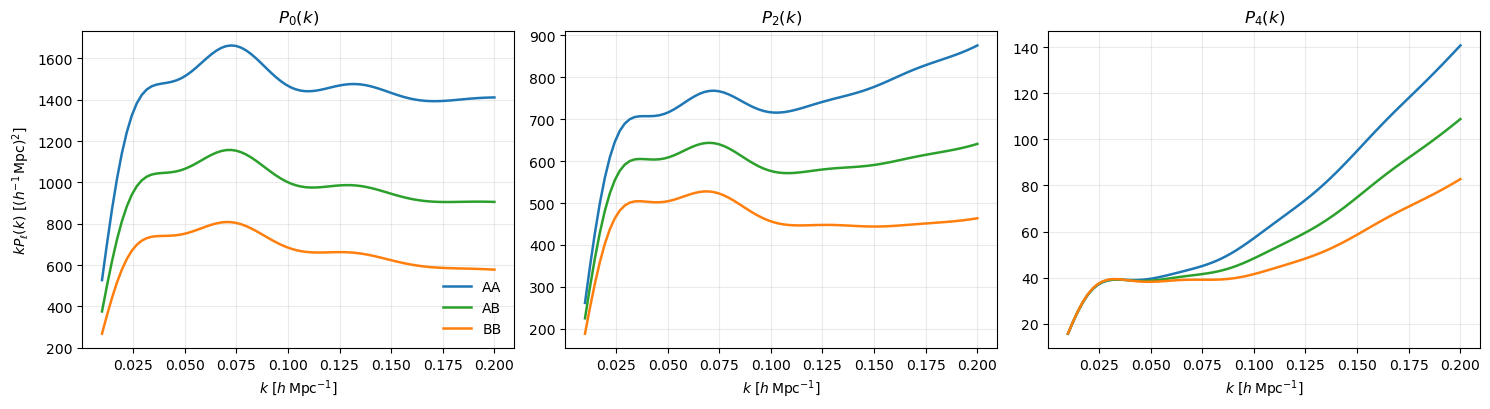

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharex=True)
series = [
    ("AA", Pell_AA, "tab:blue"),
    ("AB", Pell_AB, "tab:green"),
    ("BB", Pell_BB, "tab:orange"),
]

for index, (ell, ax) in enumerate(zip(ells, axes)):
    for label, pells, color in series:
        ax.plot(k_output, k_output * pells[index], color=color, lw=1.8, label=label)
    ax.set_title(rf"$P_{{{ell}}}(k)$")
    ax.set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
    ax.grid(alpha=0.25)
    if index == 0:
        ax.set_ylabel(r"$kP_\ell(k)\ [(h^{-1}\,\mathrm{Mpc})^2]$")
        ax.legend(frameon=False)

fig.tight_layout()
plt.show()


## Compare IR resummation on and off

The next cell recomputes $P_\ell^{AB}$ with `IR_resummation=False` and compares it to the default IR-resummed result. The purpose is to illustrate the BAO-resummation effect, not to assess model accuracy.


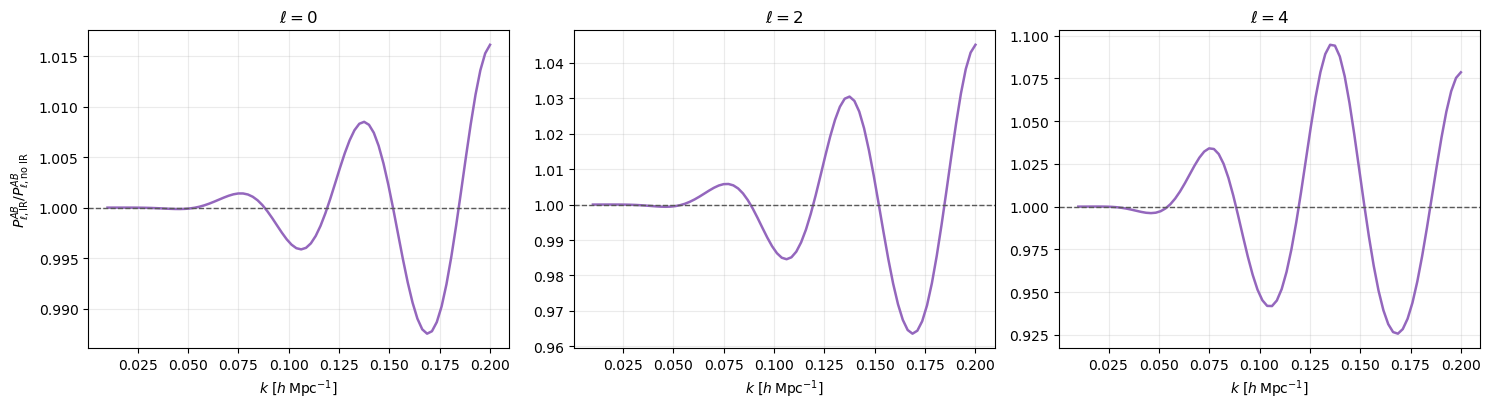

In [11]:
Pell_AB_no_ir = multipoles.get_rsd_pkell(
    pars=pars_a,
    pars_b=pars_b,
    bias_scheme_b="priordoc",
    cross_nuisance=cross_nuisance_ab,
    **{**common_pkell_kwargs, "IR_resummation": False},
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharex=True)
for index, (ell, ax) in enumerate(zip(ells, axes)):
    denom = Pell_AB_no_ir[index]
    scale = np.nanmax(np.abs(denom))
    mask = np.abs(denom) > max(scale * 1.0e-8, 1.0e-300)
    ax.plot(k_output[mask], Pell_AB[index, mask] / denom[mask], color="tab:purple", lw=1.8)
    ax.axhline(1.0, color="0.35", lw=1.0, ls="--")
    ax.set_title(rf"$\ell={ell}$")
    ax.set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
    ax.grid(alpha=0.25)
    if index == 0:
        ax.set_ylabel(r"$P_{\ell,\mathrm{IR}}^{AB}/P_{\ell,\mathrm{no\ IR}}^{AB}$")

fig.tight_layout()
plt.show()

## AP-remapping example

Here we apply a small illustrative Alcock-Paczynski distortion with `qpar = 1.02` and `qper = 0.98`. Internally, `get_rsd_pkell` remaps $k$ and $\mu$ before evaluating $P(k,\mu)$, and multiplies by the AP Jacobian $(q_\parallel q_\perp^2)^{-1}$. These numbers are illustrative only.


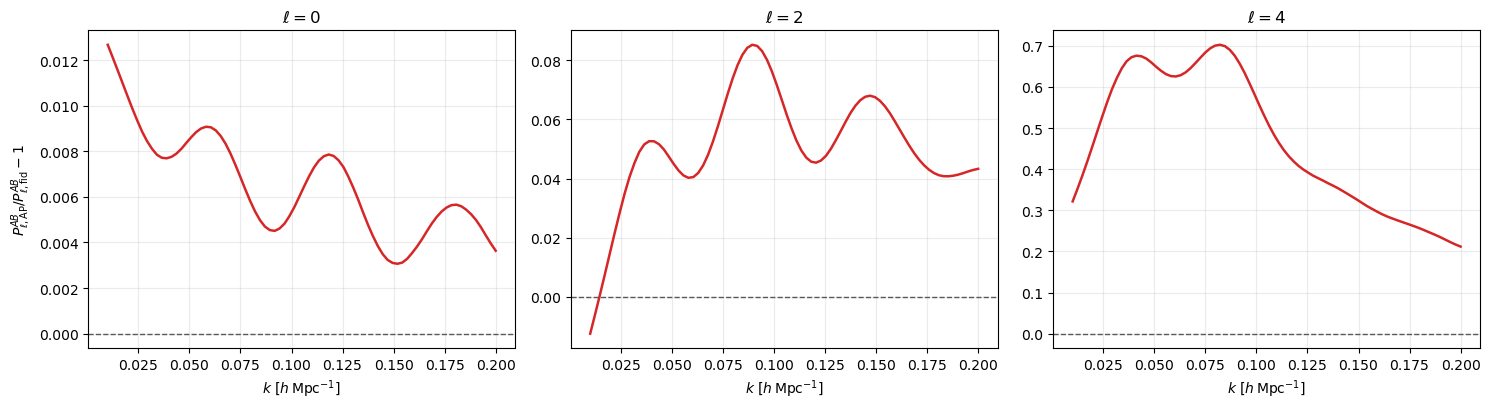

In [12]:
qpar_ap = 1.02
qper_ap = 0.98
Pell_AB_ap = multipoles.get_rsd_pkell(
    pars=pars_a,
    pars_b=pars_b,
    bias_scheme_b="priordoc",
    cross_nuisance=cross_nuisance_ab,
    **{**common_pkell_kwargs, "qpar": qpar_ap, "qper": qper_ap},
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharex=True)
for index, (ell, ax) in enumerate(zip(ells, axes)):
    denom = Pell_AB[index]
    scale = np.nanmax(np.abs(denom))
    mask = np.abs(denom) > max(scale * 1.0e-8, 1.0e-300)
    ax.plot(k_output[mask], Pell_AB_ap[index, mask] / denom[mask] - 1.0, color="tab:red", lw=1.8)
    ax.axhline(0.0, color="0.35", lw=1.0, ls="--")
    ax.set_title(rf"$\ell={ell}$")
    ax.set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
    ax.grid(alpha=0.25)
    if index == 0:
        ax.set_ylabel(r"$P_{\ell,\mathrm{AP}}^{AB}/P_{\ell,\mathrm{fid}}^{AB}-1$")

fig.tight_layout()
plt.show()

## Cross-spectrum damping

FolpsD cross spectra support the same public power-spectrum damping names as the auto path: `"exp"`, `"lor"`, and `"vdg"`. The extra keyword `cross_damping_mode` controls which FoG parameters source the cross damping.

The default is `cross_damping_mode="single"`. In this mode

$W_{AB}=W(X_{\rm FoG}^{AB}),$

so the pair-level value is `X_FoG_ab = cross_nuisance_ab[-1]`; changing `X_FoG_A` or `X_FoG_B` in the two tracer arrays does not alter the cross damping.

The alternative is `cross_damping_mode="geometric"`, where

$W_{AB}=\sqrt{W(X_{\rm FoG}^{A})W(X_{\rm FoG}^{B})}.$

In geometric mode `X_FoG_ab` remains present in `cross_nuisance_ab` for API compatibility but is ignored by the damping factor. The two modes are alternative nuisance prescriptions for mock and data comparisons, not DESI best-fit choices.


Default cross_damping_mode matches explicit single: 0.000e+00
single mode uses X_FoG_ab = cross_nuisance_ab[-1] = 1.20
Changing tracer X_FoG values in single mode max difference: 0.000e+00
Changing X_FoG_ab in geometric mode max difference: 0.000e+00
Equal-X single/geometric max difference: 0.000e+00


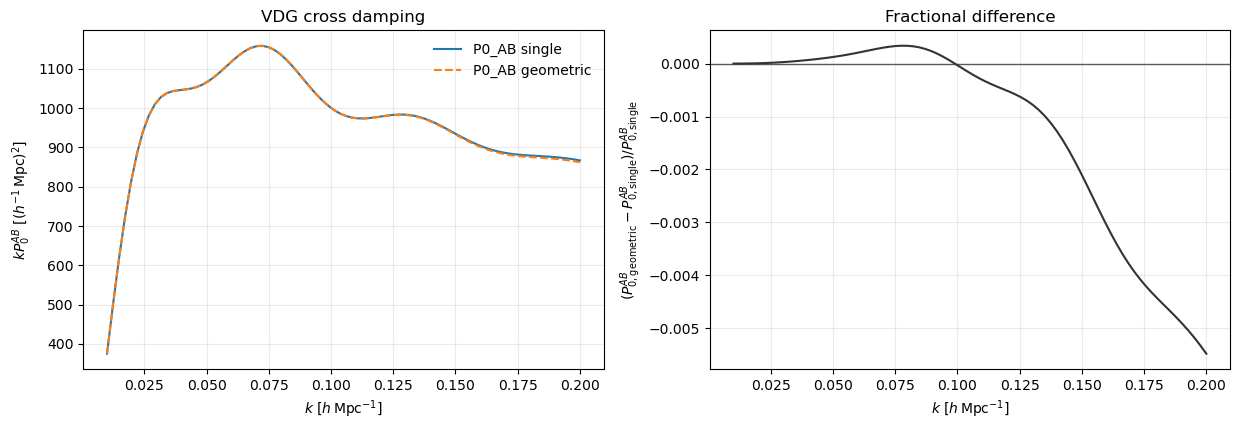

In [13]:
damping_model = RSDMultipolesPowerSpectrumCalculator(model="FOLPSD")

pars_a_damped = list(pars_a)
pars_b_damped = list(pars_b)
cross_nuisance_damped = list(cross_nuisance_ab)

# Illustrative values chosen so the two VDG damping modes visibly differ.
pars_a_damped[-1] = 0.30
pars_b_damped[-1] = 6.00
cross_nuisance_damped[-1] = 1.20
X_FoG_ab_demo = cross_nuisance_damped[-1]

common_damping_kwargs = dict(
    kobs=k_output,
    qpar=1.0,
    qper=1.0,
    table=table,
    table_now=table_now,
    bias_scheme="priordoc",
    bias_scheme_b="priordoc",
    damping="vdg",
    nmu=8,
    ells=ells,
    IR_resummation=True,
    pars_b=pars_b_damped,
    cross_nuisance=cross_nuisance_damped,
)

Pell_AB_single = damping_model.get_rsd_pkell(
    pars=pars_a_damped,
    cross_damping_mode="single",
    **common_damping_kwargs,
)
Pell_AB_single_default = damping_model.get_rsd_pkell(
    pars=pars_a_damped,
    **common_damping_kwargs,
)
Pell_AB_geometric = damping_model.get_rsd_pkell(
    pars=pars_a_damped,
    cross_damping_mode="geometric",
    **common_damping_kwargs,
)

assert np.allclose(Pell_AB_single_default, Pell_AB_single)

pars_a_single_shift = list(pars_a_damped)
pars_b_single_shift = list(pars_b_damped)
pars_a_single_shift[-1] = 7.00
pars_b_single_shift[-1] = 0.15
Pell_AB_single_shifted_tracers = damping_model.get_rsd_pkell(
    pars=pars_a_single_shift,
    pars_b=pars_b_single_shift,
    cross_damping_mode="single",
    **{key: value for key, value in common_damping_kwargs.items() if key not in {"pars_b"}},
)
assert np.allclose(Pell_AB_single_shifted_tracers, Pell_AB_single)

cross_nuisance_shifted_pair = list(cross_nuisance_damped)
cross_nuisance_shifted_pair[-1] = 8.00
Pell_AB_geometric_shifted_pair = damping_model.get_rsd_pkell(
    pars=pars_a_damped,
    cross_nuisance=cross_nuisance_shifted_pair,
    cross_damping_mode="geometric",
    **{key: value for key, value in common_damping_kwargs.items() if key not in {"cross_nuisance"}},
)
assert np.allclose(Pell_AB_geometric_shifted_pair, Pell_AB_geometric)

pars_a_equal_x = list(pars_a_damped)
pars_b_equal_x = list(pars_b_damped)
cross_nuisance_equal_x = list(cross_nuisance_damped)
pars_a_equal_x[-1] = pars_b_equal_x[-1] = cross_nuisance_equal_x[-1] = 2.40
Pell_equal_single = damping_model.get_rsd_pkell(
    pars=pars_a_equal_x,
    pars_b=pars_b_equal_x,
    cross_nuisance=cross_nuisance_equal_x,
    cross_damping_mode="single",
    **{key: value for key, value in common_damping_kwargs.items() if key not in {"pars_b", "cross_nuisance"}},
)
Pell_equal_geometric = damping_model.get_rsd_pkell(
    pars=pars_a_equal_x,
    pars_b=pars_b_equal_x,
    cross_nuisance=cross_nuisance_equal_x,
    cross_damping_mode="geometric",
    **{key: value for key, value in common_damping_kwargs.items() if key not in {"pars_b", "cross_nuisance"}},
)
assert np.allclose(Pell_equal_geometric, Pell_equal_single)

with np.errstate(divide="ignore", invalid="ignore"):
    frac_damping_p0 = np.divide(
        Pell_AB_geometric[0] - Pell_AB_single[0],
        Pell_AB_single[0],
        out=np.full_like(Pell_AB_single[0], np.nan, dtype=float),
        where=np.abs(Pell_AB_single[0]) > 1.0e-10 * max(np.max(np.abs(Pell_AB_single[0])), 1.0),
    )

print(f"Default cross_damping_mode matches explicit single: {np.max(np.abs(Pell_AB_single_default - Pell_AB_single)):.3e}")
print(f"single mode uses X_FoG_ab = cross_nuisance_ab[-1] = {X_FoG_ab_demo:.2f}")
print(f"Changing tracer X_FoG values in single mode max difference: {np.max(np.abs(Pell_AB_single_shifted_tracers - Pell_AB_single)):.3e}")
print(f"Changing X_FoG_ab in geometric mode max difference: {np.max(np.abs(Pell_AB_geometric_shifted_pair - Pell_AB_geometric)):.3e}")
print(f"Equal-X single/geometric max difference: {np.max(np.abs(Pell_equal_geometric - Pell_equal_single)):.3e}")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), sharex=True)
axes[0].plot(k_output, k_output * Pell_AB_single[0], label="P0_AB single", color="C0")
axes[0].plot(k_output, k_output * Pell_AB_geometric[0], label="P0_AB geometric", color="C1", ls="--")
axes[0].set_ylabel(r"$kP_0^{AB}\ [(h^{-1}\,\mathrm{Mpc})^2]$")
axes[0].set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
axes[0].set_title("VDG cross damping")
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False)

axes[1].axhline(0.0, color="0.35", lw=1.0)
axes[1].plot(k_output, frac_damping_p0, color="0.2")
axes[1].set_ylabel(r"$(P_{0,\rm geometric}^{AB}-P_{0,\rm single}^{AB})/P_{0,\rm single}^{AB}$")
axes[1].set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
axes[1].set_title("Fractional difference")
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()


## Inspect $P^{AB}(k,\mu)$

The multipoles are projections of the two-dimensional spectrum. For an additional diagnostic, we evaluate $P^{AB}(k,\mu)$ at selected angular slices and compare it with

$\sqrt{P^{AA}(k,\mu)P^{BB}(k,\mu)}$

only where the product is positive and numerically well defined. We also define

$r(k,\mu)=\frac{P^{AB}(k,\mu)}{\sqrt{P^{AA}(k,\mu)P^{BB}(k,\mu)}}$.

This is an illustrative model diagnostic that can be sensitive to EFT and stochastic choices. It should not be confused with a bounded correlation coefficient constructed multipole by multipole.

The lower-level `get_rsd_pkmu` helper receives canonical FOLPS parameters directly, so this diagnostic cell explicitly maps the same prior-document `pars_a` and `pars_b` with `set_bias_scheme` before calling it. The public multipole examples above keep the prior-document arrays at the API boundary through `bias_scheme="priordoc"` and `bias_scheme_b="priordoc"`.

finite r(k, mu) samples: 240 of 240
r(k, mu) range over valid samples: 0.9986 to 1.0067

Interpretation note:
Values of r(k, mu) slightly above unity do not by themselves indicate an implementation error.
The auto- and cross-spectrum EFT and stochastic parameters were chosen independently for illustration, and the truncated model does not automatically impose positive-semidefiniteness of the full two-tracer covariance.
In a physical joint analysis, this behavior should be checked against the adopted nuisance parametrization and mock measurements.
The nonzero cross stochastic values used here are arbitrary API examples: alphashot0_ab=0.01, alphashot2_ab=-0.2, PshotP_ab=3600.0.


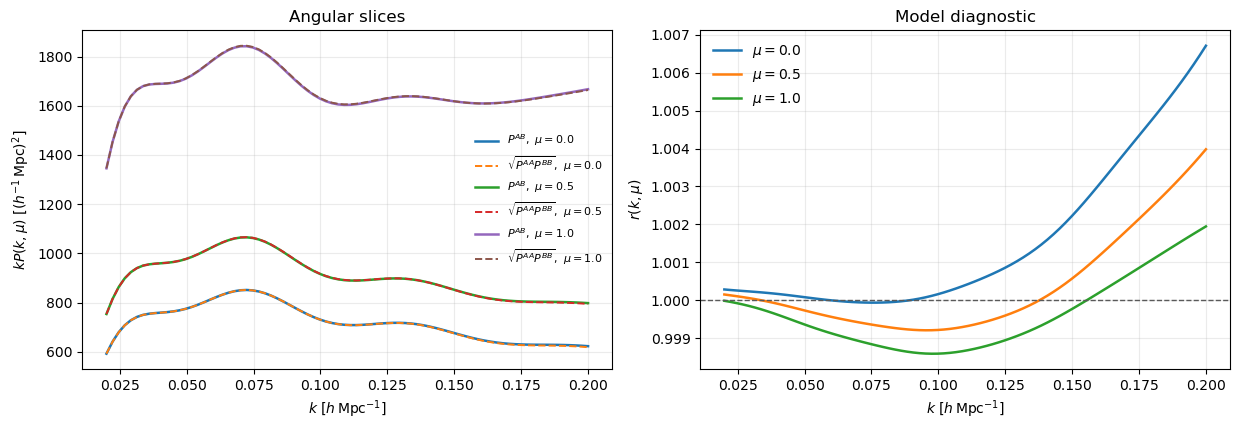

In [14]:
k_mu = np.linspace(0.02, 0.2, 80)
mu_slices = np.asarray([0.0, 0.5, 1.0])
k_grid_2d = k_mu[:, None]
mu_grid_2d = mu_slices[None, :]

pars_a_canonical = multipoles.set_bias_scheme(pars_a, bias_scheme="priordoc")
pars_b_canonical = multipoles.set_bias_scheme(pars_b, bias_scheme="priordoc")

pkmu_AB = multipoles.get_rsd_pkmu(
    k_grid_2d,
    mu_grid_2d,
    pars_a_canonical,
    table,
    table_now,
    IR_resummation=True,
    damping=None,
    pars_b=pars_b_canonical,
    cross_nuisance=cross_nuisance_ab,
)
pkmu_AA = multipoles.get_rsd_pkmu(
    k_grid_2d,
    mu_grid_2d,
    pars_a_canonical,
    table,
    table_now,
    IR_resummation=True,
    damping=None,
)
pkmu_BB = multipoles.get_rsd_pkmu(
    k_grid_2d,
    mu_grid_2d,
    pars_b_canonical,
    table,
    table_now,
    IR_resummation=True,
    damping=None,
)

product_auto = pkmu_AA * pkmu_BB
valid_geom = np.isfinite(product_auto) & (product_auto > 0.0)
geom_mean = np.full_like(pkmu_AB, np.nan, dtype=float)
r_ab = np.full_like(pkmu_AB, np.nan, dtype=float)
geom_mean[valid_geom] = np.sqrt(product_auto[valid_geom])
r_ab[valid_geom] = pkmu_AB[valid_geom] / geom_mean[valid_geom]

finite_r = r_ab[np.isfinite(r_ab)]
print(f"finite r(k, mu) samples: {finite_r.size} of {r_ab.size}")
print(f"r(k, mu) range over valid samples: {finite_r.min():.4f} to {finite_r.max():.4f}")
print()
print("Interpretation note:")
print("Values of r(k, mu) slightly above unity do not by themselves indicate an implementation error.")
print(
    "The auto- and cross-spectrum EFT and stochastic parameters were chosen independently "
    "for illustration, and the truncated model does not automatically impose positive-semidefiniteness "
    "of the full two-tracer covariance."
)
print(
    "In a physical joint analysis, this behavior should be checked against the adopted nuisance "
    "parametrization and mock measurements."
)
print(
    "The nonzero cross stochastic values used here are arbitrary API examples: "
    f"alphashot0_ab={alphashot0_ab}, alphashot2_ab={alphashot2_ab}, PshotP_ab={PshotP_ab}."
)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), sharex=True)
for index, mu_value in enumerate(mu_slices):
    axes[0].plot(k_mu, k_mu * pkmu_AB[:, index], lw=1.8, label=rf"$P^{{AB}},\ \mu={mu_value:.1f}$")
    axes[0].plot(k_mu, k_mu * geom_mean[:, index], lw=1.4, ls="--", label=rf"$\sqrt{{P^{{AA}}P^{{BB}}}},\ \mu={mu_value:.1f}$")
    axes[1].plot(k_mu, r_ab[:, index], lw=1.8, label=rf"$\mu={mu_value:.1f}$")

axes[0].set_ylabel(r"$kP(k,\mu)\ [(h^{-1}\,\mathrm{Mpc})^2]$")
axes[0].set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
axes[0].set_title(r"Angular slices")
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False, fontsize=8)

axes[1].axhline(1.0, color="0.35", lw=1.0, ls="--")
axes[1].set_ylabel(r"$r(k,\mu)$")
axes[1].set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
axes[1].set_title(r"Model diagnostic")
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=False)

fig.tight_layout()
plt.show()

## Optional term decomposition

The current public power-spectrum API cleanly exposes total $P(k,\mu)$ and multipoles, but it does not expose a stable component-wise diagnostic interface for the linear Kaiser, one-loop, EFT counterterm, and stochastic sectors. Producing such a plot here would require duplicating the production formula or relying on brittle loop-table row indices in a user-facing notebook.

A future diagnostic API could expose these pieces safely, for example by returning named components from the same pair-level contraction used by the production calculation.


## Limitations and next steps

This tutorial covers the current public equal-time two-tracer power-spectrum path only. It includes the two public FolpsD cross damping prescriptions as phenomenological nuisance examples, but it does not include redshift integration over a broad overlap bin, velocity bias, odd multipoles, wide-angle or relativistic terms, DESI window convolution, covariance or likelihood integration, or bispectrum cross-correlations.

A later DESI-specific notebook can use the LRG3-ELG1 overlap effective redshift and the actual fiducial parameter conventions for that analysis.


## Reproducibility summary

The final cell records the backend and core calculation settings used by this executed tutorial.

In [15]:
notebook_elapsed = time.perf_counter() - notebook_start

print("Tutorial completed successfully")
print("Backend: NumPy")
print("Baseline model: EFT")
print("Damping example model: FOLPSD")
print("A_full: True")
print(f"Exchange symmetry max abs: {exchange_max_abs:.3e}")
print(f"Auto-limit max abs: {auto_limit_max_abs:.3e}")
print(f"Total runtime: {notebook_elapsed:.2f} s")


Tutorial completed successfully
Backend: NumPy
Baseline model: EFT
Damping example model: FOLPSD
A_full: True
Exchange symmetry max abs: 0.000e+00
Auto-limit max abs: 0.000e+00
Total runtime: 11.61 s
